# Análisis de series temporales con `pyrcore`

In [1]:
# Librerías
try:
    from pyrcore import c,TimeSeries
except:
    %pip install -i https://test.pypi.org/simple/ pyrcore --no-deps
    from pyrcore import c,TimeSeries
try:
    import pandas as pd
except:
    %pip install pandas
    import pandas as pd
try:
    import matplotlib.pyplot as plt
except:
    %pip install matplotlib
    import matplotlib.pyplot as plt
try:
    from pmdarima.arima import ARIMA,auto_arima
except:
    %pip install pmdarima
    from pmdarima.arima import ARIMA,auto_arima
try:
    from statsmodels.tsa.seasonal import seasonal_decompose
    from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
except:
    %pip install statsmodels
    from statsmodels.tsa.seasonal import seasonal_decompose
    from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

## Importar datos

In [2]:
# Importar datos
gas=pd.read_excel("..\\datasets\\data_shale_gas_010822.xlsx",header=1)

# Previsualizar DataFrame
gas.head()

,Date,Barnett (TX),Haynesville (LA & TX),"Marcellus (PA, WV, OH & NY)",Permian (TX & NM),"Utica (OH, PA & WV)",Woodford (OK),Bakken (ND & MT),Niobrara-Codell (CO & WY),Mississippian (OK),Unnamed: 10
0,2000-01-01,0.133710,0.141004,0.000845,0.632070,0.000295,0.009290,0.013501,0.257174,0.687040,Units:
1,2000-02-01,0.139530,0.140833,0.000845,0.642394,0.000295,0.008526,0.013116,0.258500,0.694208,bcf per day
2,2000-03-01,0.150565,0.140300,0.000845,0.665302,0.000295,0.008626,0.012867,0.258599,0.704223,NaN
3,2000-04-01,0.159842,0.142965,0.000844,0.680048,0.000295,0.008810,0.013325,0.253798,0.689270,NaN
4,2000-05-01,0.163962,0.143643,0.000843,0.701509,0.000295,0.008716,0.012843,0.253023,0.724272,NaN


In [3]:
# Extraer las fechas de los extremos
fechas_og:pd.Series[pd.DatetimeIndex]=gas.Date
fechas=(c(fechas_og[0].year,fechas_og[0].month),c(fechas_og[len(fechas_og)-1].year,fechas_og[len(fechas_og)-1].month))
fechas

(c(2000, 1), c(2022, 8))

In [4]:
# Seleccionar la serie Haynesville (LA & TX)
gas=gas.iloc[:,2]
gas.head()

0    0.141004
1    0.140833
2    0.140300
3    0.142965
4    0.143643
Name: Haynesville (LA & TX), dtype: float64

In [5]:
# Convertir a TimeSeries
gas=TimeSeries(c(gas),*fechas,12)
gas

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
2000,0.14100443639862972,0.14083256530041768,0.14029952082141864,0.14296513757891463,0.14364317218065037,0.13478802779711255,0.14062803710965616,0.14072151577711936,0.13925922989888267,0.1413099114885679,0.13977071805069313,0.13621970042410003
2001,0.13019526412641505,0.13045836922403697,0.13165324734394035,0.13296215487957244,0.1375070905073496,0.1352655202122518,0.13846725334335533,0.13685377912323823,0.1304422102661082,0.13037297392579172,0.13195884412103376,0.1275573712591172
2002,0.12710716998405133,0.13040517552200392,0.1279639376439699,0.13028856366058156,0.13129054739991936,0.1332487514804749,0.1336897907416448,0.1280968043938305,0.1283757627821363,0.10567039863281341,0.1257080906026205,0.12395437127994685
2003,0.1199176378859847,0.120547386217637,0.11863174951010316,0.11404835219223294,0.11270857450999762,0.10823752007010044,0.10770097207532622,0.10414171784358169,0.10648502581294161,0.10327375649375259,0.10186781824556373,0.10130473138242224
2004,0.09665556489888426,0.09586970396090146,0.09539910298191437,0.09489545377077184,0.09570625714904941,0.09268864726389026,0.09921716209663622,0.09936309300899053,0.10370114024403826,0.100783563384835,0.10045147460547317,0.09473671086322018
2005,0.09741046944542055,0.0960695690387664,0.09233973247151578,0.09474917683289968,0.09392985792084566,0.09221106003570334,0.09319493603024206,0.09324830528454697,0.0838771532106088,0.09054161802745536,0.08959976129055167,0.0862062491646565
2006,0.08494534946783218,0.08431361948055517,0.08453368650069508,0.08458567288945854,0.08436314969918872,0.08160888783919262,0.08224000460429909,0.08189414095435021,0.08113519909084342,0.08117428816324912,0.08183196935161498,0.08189277935502888
2007,0.08259116084071014,0.08179211165982418,0.08033169224716366,0.07662892506696627,0.07910241318327652,0.07762300791778676,0.07703402810338895,0.0775295853406275,0.07895729964004827,0.07961723347670806,0.08401071185603581,0.08602543830777752
2008,0.08811637811937942,0.08466261954524149,0.08665762404255438,0.10213245757963811,0.10644899842628473,0.108713712723202,0.12204140597152435,0.13234209625256885,0.1598354390861284,0.21095199454955663,0.26785825456664875,0.3669166880715267
2009,0.41560732885743973,0.4974089180095318,0.5962023323194514,0.7503878935095919,0.8921813424589016,1.0561966615278215,1.191865787059535,1.3986761211718262,1.5914690723616987,1.8645697217932706,2.1313723375008387,2.1843520763896946


## Análisis clásico

In [6]:
# Reconvertir a pandas
gas=gas.to_pandas()
gas.index=fechas_og
gas.index

DatetimeIndex(['2000-01-01', '2000-02-01', '2000-03-01', '2000-04-01',
               '2000-05-01', '2000-06-01', '2000-07-01', '2000-08-01',
               '2000-09-01', '2000-10-01',
               ...
               '2021-11-01', '2021-12-01', '2022-01-01', '2022-02-01',
               '2022-03-01', '2022-04-01', '2022-05-01', '2022-06-01',
               '2022-07-01', '2022-08-01'],
              dtype='datetime64[us]', name='Date', length=272, freq=None)

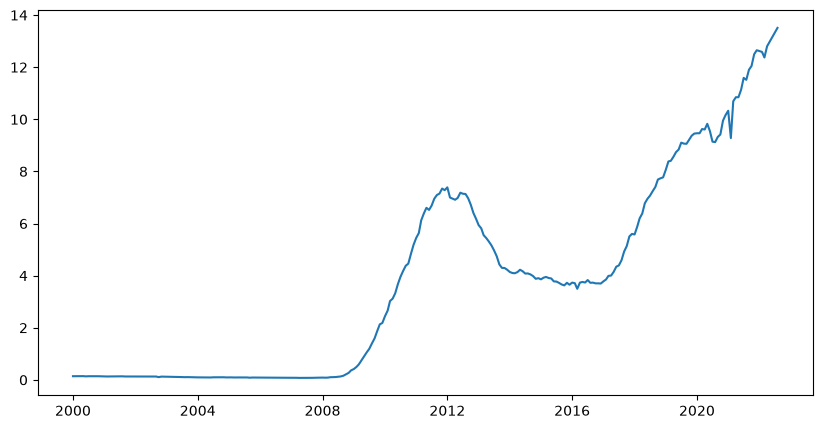

In [7]:
# Representar la serie
fig,ax=plt.subplots(figsize=(10,5))
ax.plot(gas);

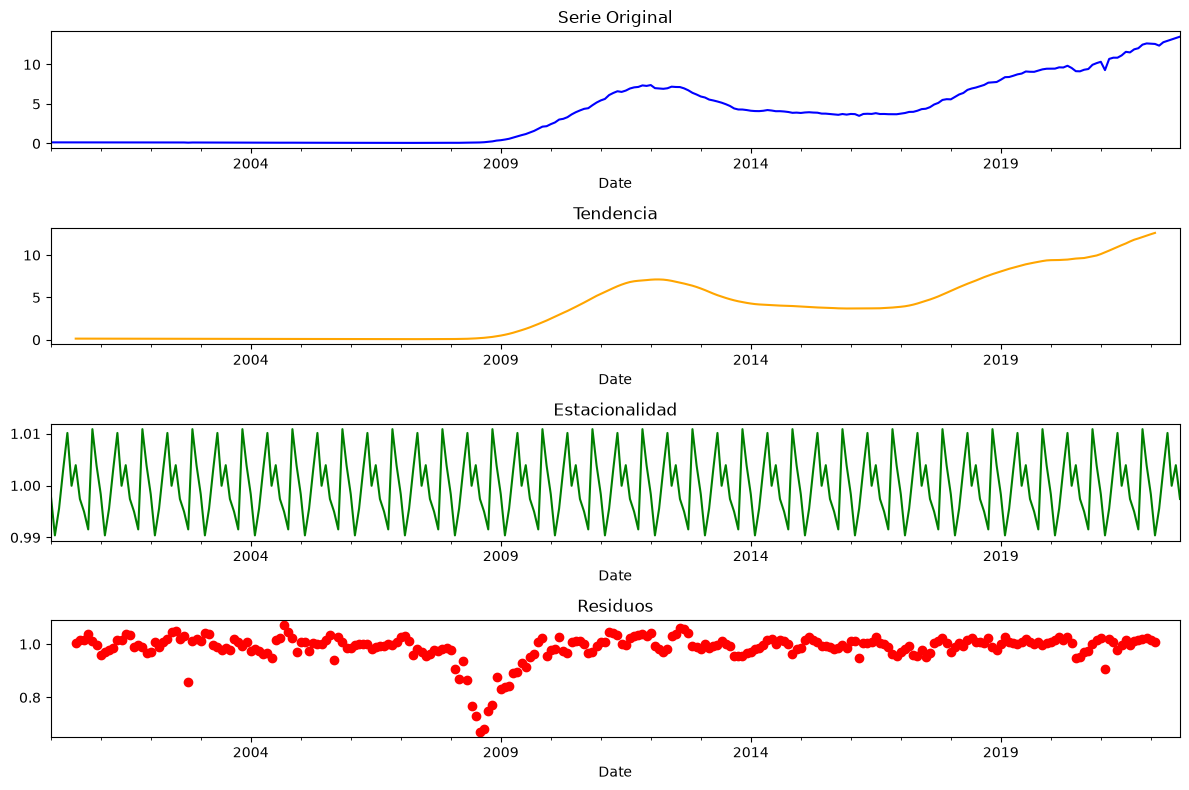

In [8]:
# Descomponer la serie
resultado=seasonal_decompose(gas,model="multiplicative")
# Visualizar los componentes
fig,ax=plt.subplots(4,1,figsize=(12,8))
resultado.observed.plot(ax=ax[0],color="blue")
ax[0].set_title("Serie Original")
resultado.trend.plot(ax=ax[1],color="orange")
ax[1].set_title("Tendencia")
resultado.seasonal.plot(ax=ax[2],color="green")
ax[2].set_title("Estacionalidad")
resultado.resid.plot(ax=ax[3],color="red",marker="o",linestyle="none")
ax[3].set_title("Residuos")
# Mostrar gráfico
plt.tight_layout();

* Se intuye una tendencia aproximadamente cuadrática, por lo que habrá que aplicar dos diferencias lineales.
* Los **Í**ndices de **V**ariación **E**stacional (**IVE**s) son muy cercanos a 1, por lo que la variación estacional no es lo bastante significativa como para requerir transformaciones estacionales.

A continuación se realiza una comprobación automatizada.

In [9]:
# Comprobación de transformaciones
from pmdarima.arima.utils import ndiffs,nsdiffs
ndiffs(gas),nsdiffs(gas,12)

(2, 0)

Efectivamente, llegamos a la conclusión de que solo hay que aplicar dos diferencias lineales.

## Separación y transformaciones

In [10]:
# Separación en conjuntos de train y test
train=gas[:-5]
test=gas[-5:]
train,test

(Date
 2000-01-01     0.141004
 2000-02-01     0.140833
 2000-03-01     0.140300
 2000-04-01     0.142965
 2000-05-01     0.143643
                 ...    
 2021-11-01    12.498925
 2021-12-01    12.651080
 2022-01-01    12.620861
 2022-02-01    12.585889
 2022-03-01    12.373100
 Length: 267, dtype: float64,
 Date
 2022-04-01    12.802725
 2022-05-01    12.975754
 2022-06-01    13.151122
 2022-07-01    13.328860
 2022-08-01    13.509000
 dtype: float64)

In [11]:
# Aplicar diferencias lineales
train=train.diff(2)
train

Date
2000-01-01         NaN
2000-02-01         NaN
2000-03-01   -0.000705
2000-04-01    0.002133
2000-05-01    0.003344
                ...   
2021-11-01    0.595789
2021-12-01    0.606205
2022-01-01    0.121936
2022-02-01   -0.065192
2022-03-01   -0.247761
Length: 267, dtype: float64

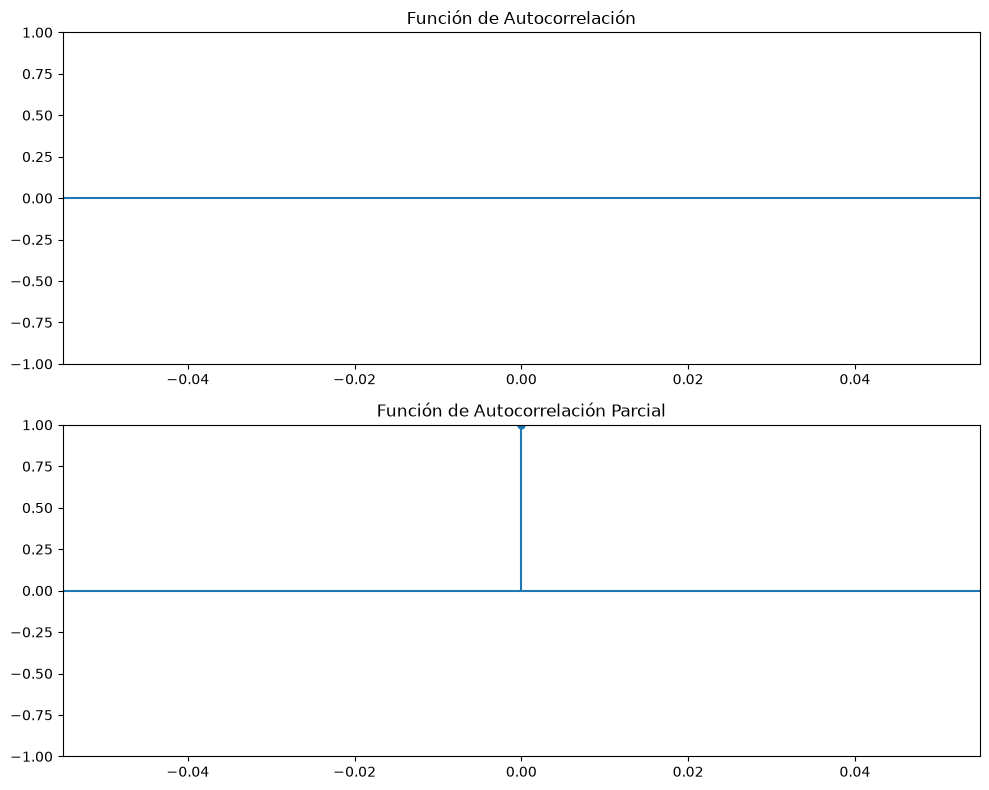

In [12]:
# Declarar elementos del gráfico
fig,ax=plt.subplots(2, 1, figsize=(10, 8))

# Correlograma de Autocorrelación (ACF)
plot_acf(train,ax=ax[0],lags=40)
ax[0].set_title("Función de Autocorrelación")

# Correlograma de Autocorrelación Parcial (PACF)
plot_pacf(train,ax=ax[1],lags=40)
ax[1].set_title("Función de Autocorrelación Parcial")

plt.tight_layout();

* **AR(p=1)**
* **Dos diferencias lineales (d=2)**
* **MA(q=2)**

Por tanto, el modelo es un **ARIMA(1,2,2)** (`p = 1`, `d = 2`, `q = 2`).

## Ajuste del modelo

In [13]:
# Se ajusta el modelo
modelo=ARIMA((1,2,2),m=12).fit(gas[:train.index[-1]]) # Se reconstruye el conjunto de entrenamiento
pred=modelo.predict(5)
pred

c:\Users\ricar\Desktop\Personal\Python\UFV\TFG\.TFG\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\ricar\Desktop\Personal\Python\UFV\TFG\.TFG\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\ricar\Desktop\Personal\Python\UFV\TFG\.TFG\Lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['m']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


2022-04-01    12.436387
2022-05-01    12.538041
2022-06-01    12.605568
2022-07-01    12.704594
2022-08-01    12.775711
Freq: MS, dtype: float64

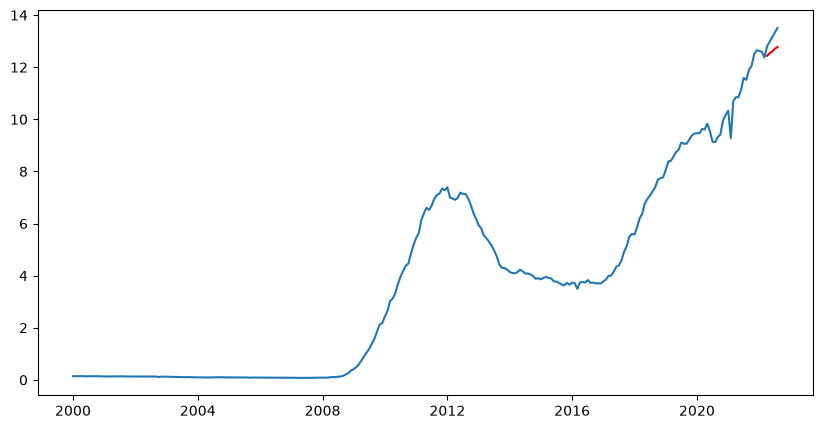

In [14]:
# Representar predicción
plt.figure(figsize=(10,5))
plt.plot(gas)
plt.plot(pred,color="red");

El análisis ha terminado y el modelo ajusta correctamente.